# 04 – Global Sensitivity Analysis

This notebook performs a Sobol sensitivity analysis and rule-induction-based feature scoring
on the "A.5_Expected Number of Deaths" outcome under a `do_nothing` policy.



## 1. Setup and Model Initialization
We
import necessary

libraries, define
the
problem, and set
up
the
model
using
formulation
3.


In [16]:
from ema_workbench import (
    Model, Policy, ema_logging,
    Samplers, MultiprocessingEvaluator,
    save_results,load_results
)

from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench.analysis import feature_scoring
from ema_workbench.analysis.scenario_discovery_util import RuleInductionType
from SALib.analyze import sobol

from dike_model_function import DikeNetwork
from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ema_logging.log_to_stderr(ema_logging.INFO)

def setup_model(formulation_index=3):
    model, planning_steps = get_model_for_problem_formulation(formulation_index)
    uncertainties = model.uncertainties.copy()
    problem = get_SALib_problem(uncertainties)
    return model, problem, uncertainties

dike_model, problem, uncertainties = setup_model()


## 2. Define Do-Nothing Policy


In [2]:
def create_do_nothing_policy(model):
    return Policy('do_nothing', **{lever.name: 0 for lever in model.levers})

donothing_policy = create_do_nothing_policy(dike_model)


## 3. Run Sobol Sampling


In [3]:
def run_sobol_experiments(model, policy, n_scenarios=2000):
    with MultiprocessingEvaluator(model) as evaluator:
        experiments, outcomes = evaluator.perform_experiments(
            scenarios=n_scenarios,
            policies=policy,
            uncertainty_sampling=Samplers.SOBOL
        )
    return experiments, outcomes

results_sobol = run_sobol_experiments(dike_model, donothing_policy)


[MainProcess/INFO] pool started with 8 workers
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
[MainProcess/INFO] performing 80000 scenarios * 1 policies * 1 model(s) = 80000 experiments
100%|██████████████████████████████████| 80000/80000 [1:10:47<00:00, 18.83it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [4]:
results_sobol

(       A.0_ID flood wave shape    A.1_Bmax A.1_Brate  A.1_pfail    A.2_Bmax  \
 0                          103  151.270435       1.0   0.737062   50.764248   
 1                           24  151.270435       1.0   0.737062   50.764248   
 2                          103  186.944515       1.0   0.737062   50.764248   
 3                          103  151.270435       1.0   0.737062   50.764248   
 4                          103  151.270435       1.0   0.680352   50.764248   
 ...                        ...         ...       ...        ...         ...   
 79995                       99  289.135758       1.0   0.183806  334.508061   
 79996                       99  289.135758       1.0   0.183806  334.508061   
 79997                       99  289.135758       1.0   0.183806  334.508061   
 79998                       99  289.135758       1.0   0.183806  334.508061   
 79999                       99  289.135758       1.0   0.183806  334.508061   
 
       A.2_Brate  A.2_pfail    A.3_Bma

In [18]:
save_results(results_sobol, "sobol_results.tar.gz")

[MainProcess/INFO] results saved successfully to /Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/final assignment/sobol_results.tar.gz


In [5]:
experiments_sobol, outcomes_sobol = results_sobol

In [15]:
outcomes_sobol

{'A.1 Total Costs': array([2.39840588e+07, 2.44043431e+07, 2.39840588e+07, ...,
        2.63883661e+09, 3.29146974e+09, 2.63883661e+09]),
 'A.1_Expected Number of Deaths': array([0.01849047, 0.01886634, 0.01849047, ..., 1.93682608, 1.93682608,
        1.93682608]),
 'A.2 Total Costs': array([2.22681318e+08, 2.42230433e+08, 2.22681318e+08, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 'A.2_Expected Number of Deaths': array([0.21553966, 0.23458191, 0.21553966, ..., 0.        , 0.        ,
        0.        ]),
 'A.3 Total Costs': array([11798034.99009779,  2207231.70342763, 11798034.99009779, ...,
               0.        ,        0.        ,        0.        ]),
 'A.3_Expected Number of Deaths': array([0.02241842, 0.00416881, 0.02241842, ..., 0.        , 0.        ,
        0.        ]),
 'A.4 Total Costs': array([0., 0., 0., ..., 0., 0., 0.]),
 'A.4_Expected Number of Deaths': array([0., 0., 0., ..., 0., 0., 0.]),
 'A.5 Total Costs': array([0., 0., 0., ..., 0., 0., 0.

In [6]:
experiments_sobol

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
0,103,151.270435,1.0,0.737062,50.764248,1.0,0.266988,236.587072,1.0,0.616681,...,0,0,0,0,0,0,0,0,do_nothing,dikesnet
1,24,151.270435,1.0,0.737062,50.764248,1.0,0.266988,236.587072,1.0,0.616681,...,0,0,0,0,0,0,0,1,do_nothing,dikesnet
2,103,186.944515,1.0,0.737062,50.764248,1.0,0.266988,236.587072,1.0,0.616681,...,0,0,0,0,0,0,0,2,do_nothing,dikesnet
3,103,151.270435,1.0,0.737062,50.764248,1.0,0.266988,236.587072,1.0,0.616681,...,0,0,0,0,0,0,0,3,do_nothing,dikesnet
4,103,151.270435,1.0,0.680352,50.764248,1.0,0.266988,236.587072,1.0,0.616681,...,0,0,0,0,0,0,0,4,do_nothing,dikesnet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,99,289.135758,1.0,0.183806,334.508061,10.0,0.687123,222.242351,10.0,0.739431,...,0,0,0,0,0,0,0,79995,do_nothing,dikesnet
79996,99,289.135758,1.0,0.183806,334.508061,10.0,0.687123,222.242351,10.0,0.739431,...,0,0,0,0,0,0,0,79996,do_nothing,dikesnet
79997,99,289.135758,1.0,0.183806,334.508061,10.0,0.687123,222.242351,10.0,0.739431,...,0,0,0,0,0,0,0,79997,do_nothing,dikesnet
79998,99,289.135758,1.0,0.183806,334.508061,10.0,0.687123,222.242351,10.0,0.739431,...,0,0,0,0,0,0,0,79998,do_nothing,dikesnet


## 4. Perform Sobol Sensitivity Analysis


In [8]:
def analyze_sobol(problem, outcome_array):
    return sobol.analyze(problem, outcome_array, calc_second_order=True, print_to_console=True)

a5_deaths = outcomes_sobol['A.5_Expected Number of Deaths']
Si = analyze_sobol(problem, a5_deaths)

def sobol_to_dataframe(Si_dict):
    return pd.DataFrame({
        'S1': Si_dict['S1'],
        'S1_conf': Si_dict['S1_conf'],
        'ST': Si_dict['ST'],
        'ST_conf': Si_dict['ST_conf']
    }, index=problem['names'])

Si_df = sobol_to_dataframe(Si)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


                               ST   ST_conf
A.0_ID flood wave shape  0.018787  0.003983
A.1_Bmax                 0.034837  0.017051
A.1_Brate                0.000597  0.000327
A.1_pfail                0.274087  0.064292
A.2_Bmax                 0.006150  0.004345
A.2_Brate                0.000345  0.000208
A.2_pfail                0.141213  0.042351
A.3_Bmax                 0.007744  0.005845
A.3_Brate                0.000649  0.000616
A.3_pfail                0.195011  0.050890
A.4_Bmax                 0.000356  0.000381
A.4_Brate                0.000011  0.000014
A.4_pfail                0.090713  0.019961
A.5_Bmax                 0.000000  0.000000
A.5_Brate                0.000000  0.000000
A.5_pfail                0.864691  0.102592
discount rate 0          0.000000  0.000000
discount rate 1          0.000000  0.000000
discount rate 2          0.000000  0.000000
                               S1   S1_conf
A.0_ID flood wave shape -0.001712  0.007270
A.1_Bmax                 0.00406

## 5. Plot Sobol Indices (Bar Plot with Error Bars)


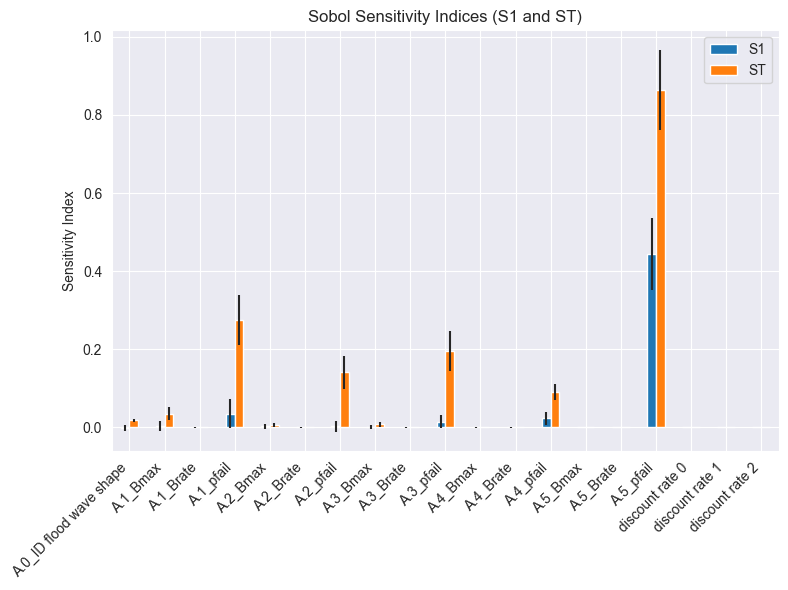

In [9]:
def plot_sobol_bars(Si_df):
    fig, ax = plt.subplots()
    indices = Si_df[['S1', 'ST']]
    errors = Si_df[['S1_conf', 'ST_conf']]
    indices.plot.bar(yerr=errors.values.T, ax=ax)
    fig.set_size_inches(8, 6)
    fig.subplots_adjust(bottom=0.3)
    plt.title("Sobol Sensitivity Indices (S1 and ST)")
    plt.ylabel("Sensitivity Index")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_sobol_bars(Si_df)


## 6. Heatmap of Sobol Indices (S1 and ST)


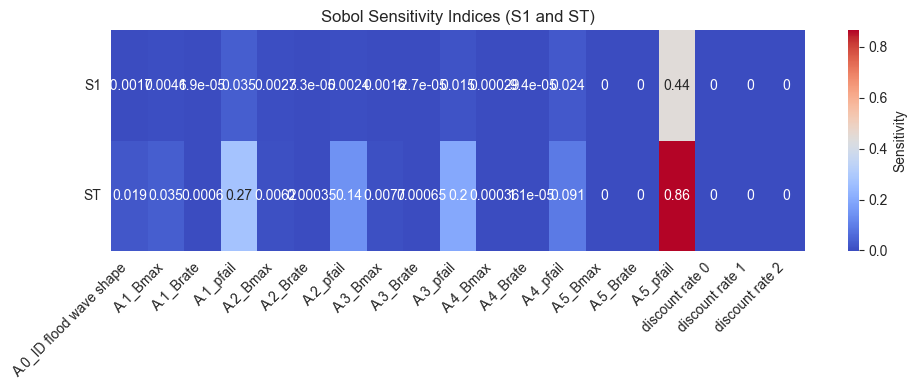

In [10]:
def plot_sobol_heatmap(Si_df):
    heatmap_data = Si_df[['S1', 'ST']].T
    plt.figure(figsize=(10, 4))
    sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', cbar_kws={'label': 'Sensitivity'})
    plt.title('Sobol Sensitivity Indices (S1 and ST)')
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_sobol_heatmap(Si_df)


## 7. Feature Scoring via Rule Induction


In [24]:
def get_feature_scores(model, experiments, outcome):
    """
    Compute feature importance using only uncertainties.

    Parameters:
        model: the EMA model (to access uncertainty names)
        experiments: DataFrame of input experiments
        outcome: 1D array or Series of the outcome to explain

    Returns:
        DataFrame with feature importance scores
    """
    # Keep only uncertainty inputs
    uncertainty_names = [u.name for u in model.uncertainties]
    experiments = experiments[uncertainty_names]

    # Run feature scoring
    scores = feature_scoring.get_ex_feature_scores(
        experiments,
        outcome,
        max_features=0.6,
        mode=RuleInductionType.REGRESSION
    )[0]

    return scores

initial_scores = get_feature_scores(dike_model, experiments_sobol, a5_deaths)
print(initial_scores)


                                1
0                                
A.5_pfail                0.568264
A.1_pfail                0.119057
A.3_pfail                0.087305
A.2_pfail                0.064416
A.4_pfail                0.038080
A.1_Bmax                 0.019319
A.3_Bmax                 0.009932
A.5_Brate                0.008937
A.2_Brate                0.008909
discount rate 1          0.008640
A.3_Brate                0.008511
A.5_Bmax                 0.008139
A.1_Brate                0.007615
discount rate 0          0.007310
A.2_Bmax                 0.007274
discount rate 2          0.007272
A.4_Brate                0.007119
A.4_Bmax                 0.007002
A.0_ID flood wave shape  0.006899


## 8. Track Feature Importance over Sample Size


In [26]:
def track_feature_scores(model, experiments, outcome, step=1000):
    """
    Tracks feature importance scores using only uncertainties over increasing sample sizes.

    Parameters:
        model: EMA model (to access uncertainty names)
        experiments: full input DataFrame
        outcome: outcome array or Series
        step: increment size for each sample batch

    Returns:
        DataFrame of feature scores over sample size
    """


    # Use only uncertainties
    uncertainty_names = [u.name for u in model.uncertainties]
    experiments = experiments[uncertainty_names]

    combined_scores = []
    for j in range(step, experiments.shape[0] + 1, step):
        scores = feature_scoring.get_ex_feature_scores(
            experiments.iloc[:j],
            outcome[:j],
            max_features=0.6,
            mode=RuleInductionType.REGRESSION
        )[0]
        scores.columns = [j]
        combined_scores.append(scores)

    return pd.concat(combined_scores, axis=1)

all_scores_df = track_feature_scores(dike_model, experiments_sobol, a5_deaths)


## 9. Plot Feature Score Heatmap


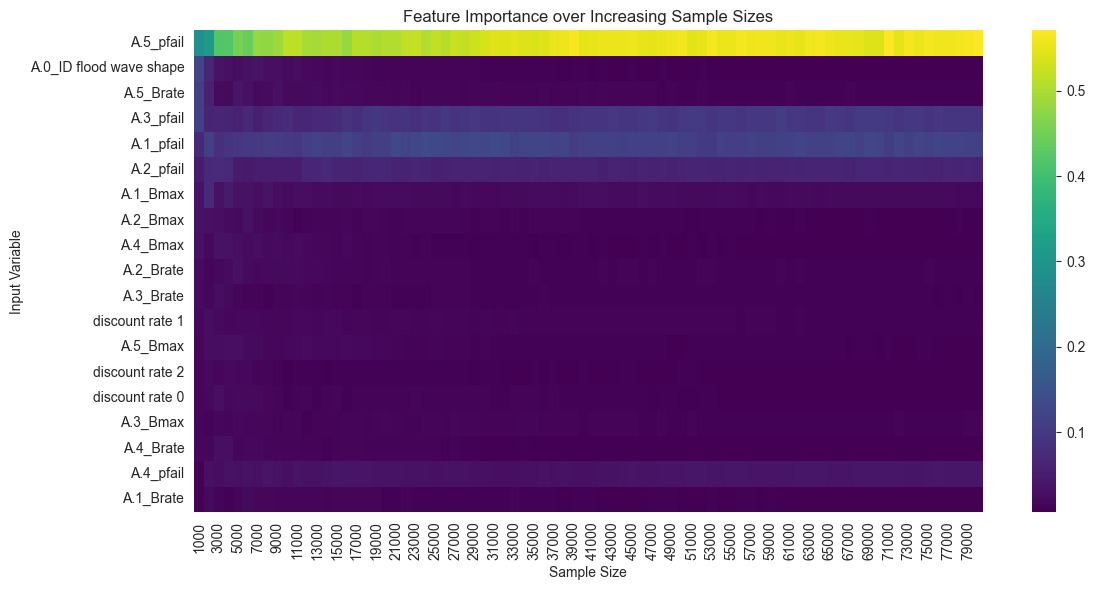

In [27]:
def plot_feature_score_heatmap(scores_df):
    plt.figure(figsize=(12, 6))
    sns.heatmap(scores_df, annot=False, cmap="viridis")
    plt.title('Feature Importance over Increasing Sample Sizes')
    plt.xlabel('Sample Size')
    plt.ylabel('Input Variable')
    plt.tight_layout()
    plt.show()

plot_feature_score_heatmap(all_scores_df)


## 10. Plot Feature Score Trends (Line Chart)


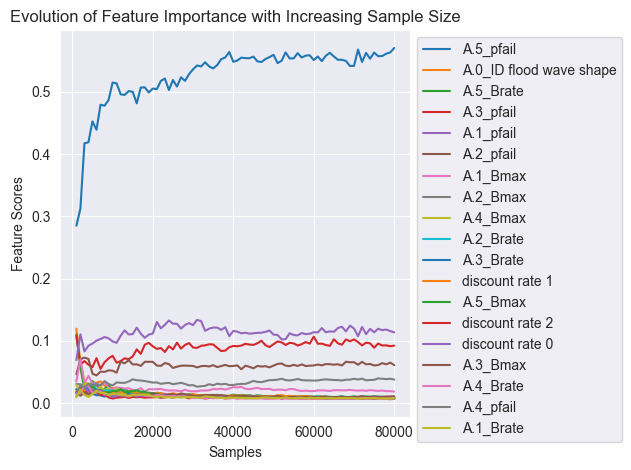

In [28]:
def plot_feature_score_trends(scores_df):
    fig, ax = plt.subplots()
    scores_df.T.plot(ax=ax)
    ax.legend(bbox_to_anchor=(1, 1))
    ax.set_xlabel('Samples')
    ax.set_ylabel('Feature Scores')
    plt.title("Evolution of Feature Importance with Increasing Sample Size")
    plt.tight_layout()
    plt.show()

plot_feature_score_trends(all_scores_df)
